Using device: cuda
Found cached TweetsDataset_translated_mixed.xlsx — loading it instead of re-translating.

10 ground-truth classes found (used only for post-hoc evaluation).
Total documents for all pipelines: 133748

=== Pipeline: mBERT + Autoencoder + K-Means ===
  [mBERT+Autoencoder+KMeans] Silhouette Score (K=10): 0.0539
    ARI=0.0142  NMI=0.0863  purity=0.6552

=== Pipeline: XLM-RoBERTa + K-Means ===
  [XLM-RoBERTa+KMeans] Silhouette Score (K=10): 0.0760
    ARI=-0.0007  NMI=0.0137  purity=0.6210

=== Pipeline: multilingual-E5 + K-Means ===
  [multilingual-E5+KMeans] Silhouette Score (K=10): 0.0270
    ARI=0.1305  NMI=0.2782  purity=0.7379

=== Pipeline: 2-layer Self-Attention (self-supervised) + K-Means ===
  [2-layer-SelfAttention(self-supervised)+KMeans] Silhouette Score (K=10): 0.0922
    ARI=0.0491  NMI=0.1667  purity=0.6637

=== Pipeline: LLM-based embeddings (XGLM-564M) + K-Means ===
  [LLM-based(XGLM-564M)+KMeans] Silhouette Score (K=10): 0.1083
    ARI=-0.0157  NMI=0.02

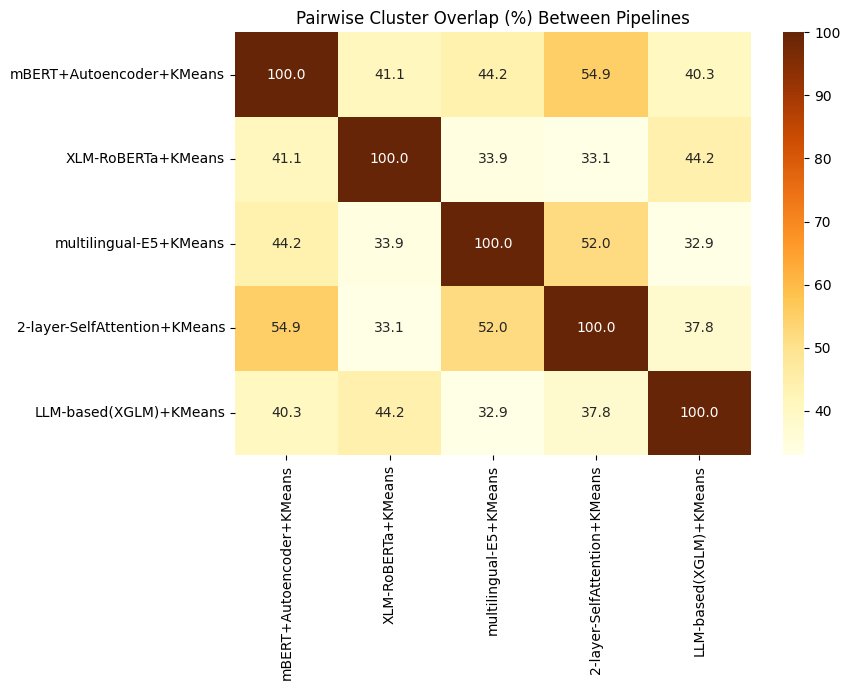


=== MASTER COMPARISON TABLE ===
                    Pipeline  Topics/K alpha beta  Epochs  Learning Rate  MSE  Silhouette Score  Coherence (c_v)  Avg Overlap w/ Others (%)     ARI    NMI  Purity
    mBERT+Autoencoder+KMeans        10  None None     5.0          0.001 None            0.0539           0.4513                       45.1  0.0142 0.0863  0.6552
          XLM-RoBERTa+KMeans        10  None None     NaN            NaN None            0.0760           0.4000                       38.1 -0.0007 0.0137  0.6210
      multilingual-E5+KMeans        10  None None     NaN            NaN None            0.0270           0.4636                       40.8  0.1305 0.2782  0.7379
2-layer-SelfAttention+KMeans        10  None None     NaN            NaN None               NaN           0.4096                       44.5     NaN    NaN     NaN
      LLM-based(XGLM)+KMeans        10  None None     NaN            NaN None               NaN           0.4203                       38.8     NaN    N

In [14]:
# 0. Translate Italian tweets to English, keeping a few Italian words
#    per tweet (code-mixed), producing the canonical dataset used below.
# 1. mBERT embeddings (shared by several pipelines).
# 2. mBERT + Autoencoder (768->64) + K-Means.
# 3. mBERT-corpus LDA (fine-tuned alpha/beta, K=10).
# 4. XLM-RoBERTa + K-Means.
# 5. multilingual-E5 + K-Means.
# 6. 2-layer Self-Attention (self-supervised, trained from scratch) + K-Means.
# 7. LLM-based embeddings (XGLM-564M, unsupervised feature extraction) + K-Means.
# 8. Comparison table: Topics/K, alpha/beta, Epochs/LR/MSE, Silhouette Score,
#    Coherence Score, pairwise Overlap (%), plus ARI/NMI/Purity vs. labels.
#
# Every expensive step caches its output to disk first and reloads it on
# re-run instead of recomputing, so this script is safe to re-run after a
# Colab/Kaggle session interruption. Toggle the RUN_* flags below to skip
# stages you don't need this session.
#
# Works in Google Colab and Kaggle Notebooks. GPU strongly recommended.

# %%
# ============================================================
# 0. SETUP — install & import everything once
# ============================================================
!pip install -q transformers torch scikit-learn pandas numpy matplotlib seaborn \
    scipy gensim nltk openpyxl ftfy langdetect sentencepiece sacremoses

import os
import re
import time
import random
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from transformers import AutoTokenizer, AutoModel, MarianMTModel, MarianTokenizer
from langdetect import detect, DetectorFactory

from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
)
from scipy.optimize import linear_sum_assignment
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

import matplotlib.pyplot as plt
import seaborn as sns

try:
    import ftfy
    HAS_FTFY = True
except ImportError:
    HAS_FTFY = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DetectorFactory.seed = SEED

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# %%
# ============================================================
# 1. CONFIG — everything in one place
# ============================================================
RAW_DATA_PATH = "/kaggle/input/datasets/szishanali/tweetsdataset1/TweetsDataset.xlsx"   # <-- EDIT if path differs
RAW_TEXT_COL = "Content"
LABEL_COL = "Classification"
ID_COL = "TwitterId"

DEDUPLICATE = True
SAMPLE_SIZE = None    

# Stage toggles — set False to skip a stage this session (its cached output
# will be reused by later stages if present).
RUN_TRANSLATION = True
RUN_AUTOENCODER = True
RUN_LDA = True
RUN_XLMR = True
RUN_E5 = True
RUN_SELF_ATTN = True
RUN_LLM = True
RUN_COMPARISON = True

N_CLUSTERS = 10
MAX_LEN = 64   # tweets are short; 128 was mostly padding waste

# Speed settings — fp16 roughly halves memory & lets batch size go up on a
# free-tier T4/P100. Only affects inference (embedding extraction) directly;
# training loops (Autoencoder, Self-Attention) use torch.autocast AMP instead.
USE_FP16 = True
COHERENCE_SAMPLE_SIZE = 100000   # cap docs fed to gensim CoherenceModel (c_v is O(n) sliding-window and dominates runtime on the full 130K corpus)

# -- Translation / code-mixing --
TRANSLATION_MODEL = "Helsinki-NLP/opus-mt-it-en"
TRANSLATE_BATCH_SIZE = 128
MIN_ITALIAN_WORDS_KEPT, MAX_ITALIAN_WORDS_KEPT = 1, 3
MIN_WORD_LEN = 4
TRANSLATED_XLSX = "TweetsDataset_translated_mixed.xlsx"
TEXT_COL = "Content_EN_mix"   # column used by every pipeline from here on

# -- mBERT embeddings (shared) --
MBERT_MODEL_NAME = "bert-base-multilingual-cased"
MBERT_EMB_PATH = "mbert_embeddings.npy"

# -- Autoencoder --
LATENT_DIM = 64
AE_EPOCHS = 5
AE_LR = 1e-3
AE_BATCH_SIZE = 64
AE_LATENT_PATH = "autoencoder_latent_features.npy"

# -- LDA --
LDA_TOPICS = N_CLUSTERS
LDA_TUNING_CSV = "lda_tuning_results.csv"

# -- XLM-R / E5 / LLM --
XLMR_MODEL_NAME = "xlm-roberta-base"
E5_MODEL_NAME = "intfloat/multilingual-e5-base"
LLM_MODEL_NAME = "facebook/xglm-564M"
EMB_BATCH_SIZE = 64   # doubled vs. before; fp16 makes this safe on a T4

# -- Self-Attention (self-supervised) --
SA_D_MODEL, SA_N_HEADS, SA_FFN_DIM, SA_N_LAYERS = 128, 4, 256, 2
SA_EPOCHS, SA_LR, SA_BATCH_SIZE, SA_MASK_PROB = 5, 1e-3, 64, 0.15

RESULTS_CSV = "clustering_results.csv"
FINAL_DATASET_XLSX = "final_all_pipelines_comparison.xlsx"
FINAL_DATASET_CSV = "final_all_pipelines_comparison.csv"

# %%
# ============================================================
# 2. SHARED HELPER FUNCTIONS
# ============================================================
def fix_mojibake(text):
    if HAS_FTFY:
        return ftfy.fix_text(text)
    try:
        return text.encode("cp1252", errors="ignore").decode("utf-8", errors="ignore")
    except Exception:
        return text

def clean_tweet(text):
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"RT\s+@\w+:?", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

def purity_score(y_true, y_pred):
    contingency = pd.crosstab(y_pred, y_true)
    return contingency.max(axis=1).sum() / contingency.values.sum()

def load_model_for_inference(model_cls, model_name, **kwargs):
    """Load a HF model for inference-only embedding extraction, in fp16 on
    GPU when enabled (roughly halves memory, frees up room for bigger
    batches — the single biggest speedup available on a free T4/P100)."""
    model = model_cls.from_pretrained(model_name, **kwargs).to(device)
    if USE_FP16 and device.type == "cuda":
        model = model.half()
    model.eval()
    return model

@torch.inference_mode()
def encode_with_hf_model(text_list, tokenizer, model, prefix="", batch_size=EMB_BATCH_SIZE,
                          normalize=False, max_len=MAX_LEN):
    all_embs = []
    for i in range(0, len(text_list), batch_size):
        batch = [prefix + t for t in text_list[i:i + batch_size]]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=max_len,
                         return_tensors="pt").to(device)
        out = model(**enc)
        pooled = mean_pool(out.last_hidden_state.float(), enc["attention_mask"])
        if normalize:
            pooled = F.normalize(pooled, p=2, dim=1)
        all_embs.append(pooled.cpu().numpy())
        if (i // batch_size) % 30 == 0:
            print(f"    embedded {i + len(batch)}/{len(text_list)}")
    return np.vstack(all_embs)

all_results = {}   # model_tag -> results dict, built up as each pipeline runs

def run_kmeans_and_evaluate(embeddings, model_tag, true_labels, extra_info=None, k=N_CLUSTERS):
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    cluster_assignments = kmeans.fit_predict(embeddings)
    sil = silhouette_score(embeddings, cluster_assignments)
    print(f"  [{model_tag}] Silhouette Score (K={k}): {sil:.4f}")

    results = {"model": model_tag, "embedding_dim": embeddings.shape[1],
               "k_clusters": k, "silhouette_score": round(sil, 4)}
    if extra_info:
        results.update(extra_info)

    if true_labels is not None:
        results["ARI"] = round(adjusted_rand_score(true_labels, cluster_assignments), 4)
        results["NMI"] = round(normalized_mutual_info_score(true_labels, cluster_assignments), 4)
        results["homogeneity"] = round(homogeneity_score(true_labels, cluster_assignments), 4)
        results["completeness"] = round(completeness_score(true_labels, cluster_assignments), 4)
        results["v_measure"] = round(v_measure_score(true_labels, cluster_assignments), 4)
        results["purity"] = round(purity_score(true_labels, cluster_assignments), 4)
        print(f"    ARI={results['ARI']:.4f}  NMI={results['NMI']:.4f}  purity={results['purity']:.4f}")

    all_results[model_tag] = results
    return cluster_assignments, results

def cluster_overlap_pct(labels_a, labels_b):
    contingency = pd.crosstab(pd.Series(labels_a), pd.Series(labels_b))
    cost = -contingency.values
    row_ind, col_ind = linear_sum_assignment(cost)
    matched = contingency.values[row_ind, col_ind].sum()
    return 100 * matched / len(labels_a)

def top_words_per_cluster_ctfidf(cluster_labels, tokenized_docs, top_n=10):
    cluster_ids = sorted(set(cluster_labels))
    cluster_word_counts = {c: {} for c in cluster_ids}
    for c, tokens in zip(cluster_labels, tokenized_docs):
        for tok in tokens:
            cluster_word_counts[c][tok] = cluster_word_counts[c].get(tok, 0) + 1
    vocab = set()
    for c in cluster_ids:
        vocab.update(cluster_word_counts[c].keys())
    doc_freq_global = {tok: sum(1 for c in cluster_ids if cluster_word_counts[c].get(tok, 0) > 0)
                        for tok in vocab}
    n_clusters_total = len(cluster_ids)
    topics = []
    for c in cluster_ids:
        total_in_cluster = sum(cluster_word_counts[c].values()) or 1
        scores = {}
        for tok, count in cluster_word_counts[c].items():
            tf = count / total_in_cluster
            idf = np.log(1 + n_clusters_total / (1 + doc_freq_global[tok]))
            scores[tok] = tf * idf
        topics.append(sorted(scores, key=scores.get, reverse=True)[:top_n])
    return topics

def compute_coherence(cluster_labels, tokenized_docs, dictionary, top_n=10):
    topics = top_words_per_cluster_ctfidf(cluster_labels, tokenized_docs, top_n=top_n)
    topics = [t for t in topics if len(t) >= 2]
    if len(topics) == 0:
        return np.nan
    cm = CoherenceModel(topics=topics, texts=tokenized_docs, dictionary=dictionary, coherence="c_v")
    return cm.get_coherence()

def tokenize_simple(text):
    return re.findall(r"[A-Za-zÀ-ÿ]{3,}", str(text).lower())

# %%
# ============================================================
# 3. LOAD, TRANSLATE & CODE-MIX (cached — skips if output already exists)
# ============================================================
if os.path.exists(TRANSLATED_XLSX):
    print(f"Found cached {TRANSLATED_XLSX} — loading it instead of re-translating.")
    df = pd.read_excel(TRANSLATED_XLSX)
elif RUN_TRANSLATION:
    df = pd.read_excel(RAW_DATA_PATH)
    df = df.dropna(subset=[RAW_TEXT_COL]).reset_index(drop=True)

    if DEDUPLICATE:
        before = len(df)
        df = df.drop_duplicates(subset=[RAW_TEXT_COL]).reset_index(drop=True)
        print(f"Removed {before - len(df)} duplicate tweets ({before} -> {len(df)})")

    df[RAW_TEXT_COL] = df[RAW_TEXT_COL].astype(str).apply(fix_mojibake)

    if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
        df = df.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
        print(f"Subsampled to {len(df)} rows")

    print("Detecting language per tweet...")
    def safe_detect(text):
        try:
            stripped = re.sub(r"http\S+|www\.\S+|@\w+|#\w+", "", text).strip()
            if len(stripped) < 8:
                return "unknown"
            return detect(stripped)
        except Exception:
            return "unknown"
    df["detected_lang"] = df[RAW_TEXT_COL].apply(safe_detect)
    is_italian = df["detected_lang"] == "it"
    print(f"{is_italian.sum()} Italian tweets to translate; {(~is_italian).sum()} left unchanged")

    ITALIAN_STOPWORDS = set("""
    a ad al alla allo ai agli agl' all' alle con col coi da dal dallo dall'
    dagli dai dagl' dalle di del dello dell' degli delle in nel nello nell'
    negli nella nelle su sul sullo sull' sugli sulla sulle per tra fra
    un uno una un' e ed o od che chi cui non come dove quando gia anche
    piu meno molto poco tanto tutto tutti tutta tutte questo questi
    questa queste quello quelli quella quelle io tu lui lei noi voi loro
    mi ti si ci vi lo la le li gli ne del della dei delle sono sei siamo
    siete essere stato stata stati state ho hai ha abbiamo avete hanno
    essendo avendo era erano ero eri eravamo eravate perche quindi
    mentre dopo prima ancora sempre mai qui qua li la ma pero se rt via
    """.split())
    WORD_RE = re.compile(r"[A-Za-zÀ-ÿ]+")

    def pick_keep_words(original_text):
        cleaned = re.sub(r"http\S+|www\.\S+|@\w+|#\w+|\bRT\b", " ", original_text)
        candidates = [w for w in WORD_RE.findall(cleaned)
                      if len(w) >= MIN_WORD_LEN and w.lower() not in ITALIAN_STOPWORDS]
        if not candidates:
            return []
        k = min(len(candidates), random.randint(MIN_ITALIAN_WORDS_KEPT, MAX_ITALIAN_WORDS_KEPT))
        return random.sample(candidates, k)

    tokenizer_mt = MarianTokenizer.from_pretrained(TRANSLATION_MODEL)
    translator = load_model_for_inference(MarianMTModel, TRANSLATION_MODEL)

    @torch.no_grad()
    def translate_batch(text_list, batch_size=TRANSLATE_BATCH_SIZE):
        outputs = []
        for i in range(0, len(text_list), batch_size):
            batch = text_list[i:i + batch_size]
            enc = tokenizer_mt(batch, return_tensors="pt", padding=True,
                                truncation=True, max_length=MAX_LEN).to(device)
            gen = translator.generate(**enc, max_length=MAX_LEN, num_beams=1)
            outputs.extend(tokenizer_mt.batch_decode(gen, skip_special_tokens=True))
            if (i // batch_size) % 30 == 0:
                print(f"    translated {i + len(batch)}/{len(text_list)}")
        return outputs

    italian_idx = df.index[is_italian].tolist()
    italian_texts = df.loc[italian_idx, RAW_TEXT_COL].tolist()
    print(f"Translating {len(italian_texts)} Italian tweets...")
    translated_full = translate_batch(italian_texts)

    keep_words_per_tweet = [pick_keep_words(t) for t in italian_texts]
    flat_words, word_owner = [], []
    for local_i, words in enumerate(keep_words_per_tweet):
        for w in words:
            flat_words.append(w)
            word_owner.append(local_i)
    print(f"Translating {len(flat_words)} individual keep-words for code-mixing...")
    translated_words = translate_batch(flat_words) if flat_words else []

    word_translation_map = {}
    for owner, it_word, en_word in zip(word_owner, flat_words, translated_words):
        word_translation_map.setdefault(owner, []).append((it_word, en_word.strip()))

    def insert_italian_words(english_sentence, word_pairs):
        result = english_sentence
        for it_word, en_word in word_pairs:
            en_word_clean = re.sub(r"[^\w]", "", en_word)
            if not en_word_clean:
                continue
            pattern = re.compile(rf"\b{re.escape(en_word_clean)}\b", flags=re.IGNORECASE)
            if pattern.search(result):
                result = pattern.sub(it_word, result, count=1)
        return result

    mixed_texts = [insert_italian_words(base, word_translation_map.get(i, []))
                   for i, base in enumerate(translated_full)]

    df[TEXT_COL] = df[RAW_TEXT_COL]
    for idx, mixed in zip(italian_idx, mixed_texts):
        df.at[idx, TEXT_COL] = mixed
    df["was_translated"] = False
    df.loc[italian_idx, "was_translated"] = True

    df.to_excel(TRANSLATED_XLSX, index=False)
    df.to_csv(TRANSLATED_XLSX.replace(".xlsx", ".csv"), index=False)
    print(f"Saved {TRANSLATED_XLSX}")

    del translator
    if device.type == "cuda":
        torch.cuda.empty_cache()
else:
    raise FileNotFoundError(
        f"{TRANSLATED_XLSX} not found and RUN_TRANSLATION=False — "
        "either enable RUN_TRANSLATION or provide the file."
    )

if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
    df = df.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)

texts_clean = [clean_tweet(str(t)) for t in df[TEXT_COL].astype(str).tolist()]
df["text_clean"] = texts_clean

has_labels = LABEL_COL in df.columns
if has_labels:
    unique_labels = sorted(df[LABEL_COL].astype(str).unique())
    label_to_id = {lab: i for i, lab in enumerate(unique_labels)}
    true_labels = df[LABEL_COL].astype(str).map(label_to_id).values
    print(f"\n{len(unique_labels)} ground-truth classes found (used only for post-hoc evaluation).")
else:
    true_labels = None
    print("\nNo label column found — running fully unsupervised.")

print(f"Total documents for all pipelines: {len(df)}")

# %%
# ============================================================
# 4. mBERT EMBEDDINGS (shared by Autoencoder pipeline + LDA silhouette scoring)
# ============================================================
if os.path.exists(MBERT_EMB_PATH):
    mbert_embeddings = np.load(MBERT_EMB_PATH)
    if mbert_embeddings.shape[0] != len(df):
        print("Cached mBERT embeddings size mismatch — regenerating.")
        mbert_embeddings = None
else:
    mbert_embeddings = None

if mbert_embeddings is None:
    print("\nGenerating mBERT embeddings (768-dim)...")
    tok_mbert = AutoTokenizer.from_pretrained(MBERT_MODEL_NAME)
    model_mbert = load_model_for_inference(AutoModel, MBERT_MODEL_NAME)
    t0 = time.time()
    mbert_embeddings = encode_with_hf_model(texts_clean, tok_mbert, model_mbert, batch_size=EMB_BATCH_SIZE)
    print(f"Done in {time.time()-t0:.1f}s. Shape: {mbert_embeddings.shape}")
    np.save(MBERT_EMB_PATH, mbert_embeddings)
    del model_mbert
    if device.type == "cuda":
        torch.cuda.empty_cache()

# %%
# ============================================================
# 5. mBERT + AUTOENCODER (768 -> 64) + K-MEANS
# ============================================================
if RUN_AUTOENCODER:
    print("\n=== Pipeline: mBERT + Autoencoder + K-Means ===")

    class Autoencoder(nn.Module):
        def __init__(self, input_dim=768, latent_dim=64):
            super().__init__()
            self.encoder = nn.Sequential(nn.Linear(input_dim, 256), nn.ReLU(),
                                          nn.Linear(256, latent_dim))
            self.decoder = nn.Sequential(nn.Linear(latent_dim, 256), nn.ReLU(),
                                          nn.Linear(256, input_dim))
        def forward(self, x):
            z = self.encoder(x)
            return self.decoder(z), z

    if os.path.exists(AE_LATENT_PATH):
        latent = np.load(AE_LATENT_PATH)
        final_mse = None
        if latent.shape[0] != len(df):
            latent = None
    else:
        latent = None

    if latent is None:
        emb_mean = mbert_embeddings.mean(axis=0, keepdims=True)
        emb_std = mbert_embeddings.std(axis=0, keepdims=True) + 1e-8
        embeddings_norm = (mbert_embeddings - emb_mean) / emb_std

        X = torch.tensor(embeddings_norm, dtype=torch.float32)
        loader = DataLoader(TensorDataset(X), batch_size=AE_BATCH_SIZE, shuffle=True)

        ae = Autoencoder(input_dim=mbert_embeddings.shape[1], latent_dim=LATENT_DIM).to(device)
        optimizer = torch.optim.AdamW(ae.parameters(), lr=AE_LR)
        criterion = nn.MSELoss()

        print("Training Autoencoder...")
        ae.train()
        history = []
        for epoch in range(1, AE_EPOCHS + 1):
            epoch_loss = 0.0
            for (batch,) in loader:
                batch = batch.to(device)
                optimizer.zero_grad()
                recon, _ = ae(batch)
                loss = criterion(recon, batch)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * batch.size(0)
            epoch_loss /= len(X)
            history.append(epoch_loss)
            print(f"  Epoch {epoch}/{AE_EPOCHS} - MSE loss: {epoch_loss:.4f}")
        final_mse = history[-1]

        ae.eval()
        with torch.no_grad():
            _, latent = ae(X.to(device))
            latent = latent.cpu().numpy()
        np.save(AE_LATENT_PATH, latent)

        del ae
        if device.type == "cuda":
            torch.cuda.empty_cache()

    clusters_ae, results_ae = run_kmeans_and_evaluate(
        latent, "mBERT+Autoencoder+KMeans", true_labels,
        extra_info={"epochs": AE_EPOCHS, "learning_rate": AE_LR,
                    "mse": round(final_mse, 4) if final_mse is not None else None},
    )
    df["cluster_autoencoder"] = clusters_ae

# %%
# ============================================================
# 6. mBERT-CORPUS LDA (fine-tuned alpha/beta, K=10)
# ============================================================
if RUN_LDA:
    print("\n=== Pipeline: mBERT-corpus LDA ===")

    ITALIAN_STOPWORDS_LDA = set("""
    a ad al alla allo ai agli agl' all' alle con col coi da dal dallo dall'
    dagli dai dagl' dalle di del dello dell' degli delle in nel nello nell'
    negli nella nelle su sul sullo sull' sugli sulla sulle per tra fra
    un uno una un' e ed o od che chi cui non come dove quando gia anche
    piu meno molto poco tanto tutto tutti tutta tutte questo questi
    questa queste quello quelli quella quelle io tu lui lei noi voi loro
    mi ti si ci vi lo la le li gli ne del della dei delle sono sei siamo
    siete essere stato stata stati state ho hai ha abbiamo avete hanno
    essendo avendo era erano ero eri eravamo eravate perche quindi
    mentre dopo prima ancora sempre mai qui qua li la ma pero se rt via
    """.split())
    STOPWORDS = list(ITALIAN_STOPWORDS_LDA) + list(
        CountVectorizer(stop_words="english").get_stop_words() or []
    )
    vectorizer = CountVectorizer(max_df=0.90, min_df=5, stop_words=STOPWORDS,
                                  token_pattern=r"(?u)\b[^\W\d_][^\W\d_]+\b")
    dtm = vectorizer.fit_transform(df["text_clean"])
    vocab = vectorizer.get_feature_names_out()
    print(f"Document-term matrix shape: {dtm.shape}")

    dtm_train, dtm_val = train_test_split(dtm, test_size=0.2, random_state=SEED)
    param_grid = [
        {"doc_topic_prior": None, "topic_word_prior": None, "learning_decay": 0.7},
        {"doc_topic_prior": 0.1, "topic_word_prior": 0.01, "learning_decay": 0.7},
        {"doc_topic_prior": 0.1, "topic_word_prior": 0.1, "learning_decay": 0.5},
        {"doc_topic_prior": 0.5, "topic_word_prior": 0.01, "learning_decay": 0.7},
        {"doc_topic_prior": 0.05, "topic_word_prior": 0.05, "learning_decay": 0.9},
    ]
    print("Tuning LDA hyperparameters...")
    tuning_rows, best_score, best_params = [], -np.inf, None
    for params in param_grid:
        lda = LatentDirichletAllocation(
            n_components=LDA_TOPICS, doc_topic_prior=params["doc_topic_prior"],
            topic_word_prior=params["topic_word_prior"], learning_decay=params["learning_decay"],
            learning_method="online", max_iter=25, random_state=SEED, n_jobs=-1,
        )
        lda.fit(dtm_train)
        ll = lda.score(dtm_val)
        perplexity = lda.perplexity(dtm_val)
        row = {"doc_topic_prior (alpha)": params["doc_topic_prior"] or f"1/{LDA_TOPICS} (default)",
               "topic_word_prior (beta)": params["topic_word_prior"] or f"1/{LDA_TOPICS} (default)",
               "learning_decay": params["learning_decay"],
               "held_out_log_likelihood": round(ll, 1), "perplexity": round(perplexity, 1)}
        tuning_rows.append(row)
        print(" ", row)
        if ll > best_score:
            best_score, best_params = ll, params

    tuning_df = pd.DataFrame(tuning_rows)
    tuning_df.to_csv(LDA_TUNING_CSV, index=False)
    print("Best LDA hyperparameters:", best_params)

    final_lda = LatentDirichletAllocation(
        n_components=LDA_TOPICS, doc_topic_prior=best_params["doc_topic_prior"],
        topic_word_prior=best_params["topic_word_prior"], learning_decay=best_params["learning_decay"],
        learning_method="online", max_iter=50, random_state=SEED, n_jobs=1,   # <-- was -1
    )
    doc_topic_dist = final_lda.fit_transform(dtm)
    lda_clusters = doc_topic_dist.argmax(axis=1)
    df["cluster_lda"] = lda_clusters

    def top_words_per_topic(model, vocab, n_words=12):
        return {idx: [vocab[i] for i in topic.argsort()[::-1][:n_words]]
                for idx, topic in enumerate(model.components_)}
    topic_words = top_words_per_topic(final_lda, vocab)
    pd.DataFrame({f"topic_{t}": w for t, w in topic_words.items()}).to_csv(
        "lda_topic_top_words.csv", index=False)

    # Silhouette scored in the SAME feature space as the Autoencoder pipeline,
    # so the two K=10 clusterings are directly comparable.
    sil_space = latent if RUN_AUTOENCODER else mbert_embeddings
    sil_lda = silhouette_score(sil_space, lda_clusters)
    print(f"LDA Silhouette Score (K={LDA_TOPICS}, scored in Autoencoder latent space): {sil_lda:.4f}")

    results_lda = {
        "model": "mBERT-corpus+LDA", "k_clusters": LDA_TOPICS,
        "doc_topic_prior": best_params["doc_topic_prior"], "topic_word_prior": best_params["topic_word_prior"],
        "held_out_log_likelihood": round(best_score, 1), "silhouette_score": round(sil_lda, 4),
    }
    if true_labels is not None:
        results_lda["ARI"] = round(adjusted_rand_score(true_labels, lda_clusters), 4)
        results_lda["NMI"] = round(normalized_mutual_info_score(true_labels, lda_clusters), 4)
        results_lda["homogeneity"] = round(homogeneity_score(true_labels, lda_clusters), 4)
        results_lda["completeness"] = round(completeness_score(true_labels, lda_clusters), 4)
        results_lda["v_measure"] = round(v_measure_score(true_labels, lda_clusters), 4)
        results_lda["purity"] = round(purity_score(true_labels, lda_clusters), 4)
    all_results["mBERT-corpus+LDA"] = results_lda

# %%
# ============================================================
# 7. XLM-ROBERTA + K-MEANS
# ============================================================
if RUN_XLMR:
    print("\n=== Pipeline: XLM-RoBERTa + K-Means ===")
    if os.path.exists("xlmr_embeddings.npy"):
        emb_xlmr = np.load("xlmr_embeddings.npy")
    else:
        tok = AutoTokenizer.from_pretrained(XLMR_MODEL_NAME)
        model = load_model_for_inference(AutoModel, XLMR_MODEL_NAME)
        emb_xlmr = encode_with_hf_model(texts_clean, tok, model)
        np.save("xlmr_embeddings.npy", emb_xlmr)
        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()
    clusters_xlmr, _ = run_kmeans_and_evaluate(
        emb_xlmr, "XLM-RoBERTa+KMeans", true_labels, extra_info={"backbone": XLMR_MODEL_NAME})
    df["cluster_xlmr"] = clusters_xlmr

# %%
# ============================================================
# 8. MULTILINGUAL-E5 + K-MEANS
# ============================================================
if RUN_E5:
    print("\n=== Pipeline: multilingual-E5 + K-Means ===")
    if os.path.exists("e5_embeddings.npy"):
        emb_e5 = np.load("e5_embeddings.npy")
    else:
        tok = AutoTokenizer.from_pretrained(E5_MODEL_NAME)
        model = load_model_for_inference(AutoModel, E5_MODEL_NAME)
        emb_e5 = encode_with_hf_model(texts_clean, tok, model, prefix="query: ", normalize=True)
        np.save("e5_embeddings.npy", emb_e5)
        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()
    clusters_e5, _ = run_kmeans_and_evaluate(
        emb_e5, "multilingual-E5+KMeans", true_labels, extra_info={"backbone": E5_MODEL_NAME})
    df["cluster_e5"] = clusters_e5

# %%
# ============================================================
# 9. 2-LAYER SELF-ATTENTION (SELF-SUPERVISED, TRAINED FROM SCRATCH) + K-MEANS
# ============================================================
if RUN_SELF_ATTN:
    print("\n=== Pipeline: 2-layer Self-Attention (self-supervised) + K-Means ===")
    if os.path.exists("self_attention_embeddings.npy"):
        emb_self_attn = np.load("self_attention_embeddings.npy")
        sa_final_loss = None
    else:
        sa_tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
        VOCAB_SIZE = sa_tokenizer.vocab_size
        PAD_ID, MASK_ID = sa_tokenizer.pad_token_id, sa_tokenizer.mask_token_id
        CLS_ID, SEP_ID = sa_tokenizer.cls_token_id, sa_tokenizer.sep_token_id

        enc = sa_tokenizer(texts_clean, padding="max_length", truncation=True,
                            max_length=MAX_LEN, return_tensors="pt")
        input_ids_all, attn_mask_all = enc["input_ids"], enc["attention_mask"]

        class SelfAttentionEncoder(nn.Module):
            def __init__(self, vocab_size, d_model, n_heads, ffn_dim, n_layers, max_len):
                super().__init__()
                self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
                self.pos_emb = nn.Embedding(max_len, d_model)
                layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
                                                    dim_feedforward=ffn_dim, batch_first=True,
                                                    activation="gelu")
                self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers,
                                                      enable_nested_tensor=False)   # <-- FIX 1
                self.mlm_head = nn.Linear(d_model, vocab_size)
            def forward(self, input_ids, attention_mask):
                positions = torch.arange(input_ids.size(1), device=input_ids.device).unsqueeze(0)
                x = self.token_emb(input_ids) + self.pos_emb(positions)
                pad_mask = (attention_mask == 0).to(x.device)                     # <-- FIX 2
                hidden = self.encoder(x, src_key_padding_mask=pad_mask)
                return hidden, self.mlm_head(hidden)

        def mask_tokens(input_ids, mask_prob=SA_MASK_PROB):
            labels = input_ids.clone()
            special = (input_ids == PAD_ID) | (input_ids == CLS_ID) | (input_ids == SEP_ID)
            prob_matrix = torch.full(input_ids.shape, mask_prob, device=input_ids.device)   # <-- FIX
            prob_matrix.masked_fill_(special, 0.0)
            masked_positions = torch.bernoulli(prob_matrix).bool()
            labels[~masked_positions] = -100
            masked_input = input_ids.clone()
            masked_input[masked_positions] = MASK_ID
            return masked_input, labels

        sa_model = SelfAttentionEncoder(VOCAB_SIZE, SA_D_MODEL, SA_N_HEADS, SA_FFN_DIM,
                                         SA_N_LAYERS, MAX_LEN).to(device)
        sa_optimizer = torch.optim.AdamW(sa_model.parameters(), lr=SA_LR)
        sa_loader = DataLoader(TensorDataset(input_ids_all, attn_mask_all),
                                batch_size=SA_BATCH_SIZE, shuffle=True)

        # Mixed-precision (AMP) training: this model's output layer is
        # vocab_size-wide (~120K), so the loss computation is the real cost
        # here — autocast + GradScaler noticeably speeds this up on a T4.
        use_amp = USE_FP16 and device.type == "cuda"
        scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

        print("Training self-supervised self-attention encoder...")
        sa_model.train()
        sa_history = []
        for epoch in range(1, SA_EPOCHS + 1):
            epoch_loss, n_batches = 0.0, 0
            for batch_ids, batch_mask in sa_loader:
                batch_ids, batch_mask = batch_ids.to(device), batch_mask.to(device)
                masked_input, labels = mask_tokens(batch_ids)
                sa_optimizer.zero_grad()
                with torch.autocast(device_type=device.type, enabled=use_amp):
                    _, logits = sa_model(masked_input, batch_mask)
                    loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE), labels.view(-1), ignore_index=-100)
                scaler.scale(loss).backward()
                scaler.step(sa_optimizer)
                scaler.update()
                epoch_loss += loss.item()
                n_batches += 1
            epoch_loss /= max(n_batches, 1)
            sa_history.append(epoch_loss)
            print(f"  Epoch {epoch}/{SA_EPOCHS} - masked-token CE loss: {epoch_loss:.4f}")
        sa_final_loss = sa_history[-1]

        sa_model.eval()
        all_sa_embs = []
        with torch.no_grad():
            for i in range(0, len(df), EMB_BATCH_SIZE):
                batch_ids = input_ids_all[i:i + EMB_BATCH_SIZE].to(device)
                batch_mask = attn_mask_all[i:i + EMB_BATCH_SIZE].to(device)
                hidden, _ = sa_model(batch_ids, batch_mask)
                all_sa_embs.append(mean_pool(hidden, batch_mask).cpu().numpy())
        emb_self_attn = np.vstack(all_sa_embs)
        np.save("self_attention_embeddings.npy", emb_self_attn)
        del sa_model
        if device.type == "cuda":
            torch.cuda.empty_cache()

    clusters_sa, _ = run_kmeans_and_evaluate(
        emb_self_attn, "2-layer-SelfAttention(self-supervised)+KMeans", true_labels,
        extra_info={"epochs": SA_EPOCHS, "learning_rate": SA_LR,
                    "final_mlm_loss": round(sa_final_loss, 4) if sa_final_loss is not None else None},
    )
    df["cluster_self_attn"] = clusters_sa

# %%
# ============================================================
# 10. LLM-BASED EMBEDDINGS (XGLM-564M, unsupervised) + K-MEANS
# ============================================================
if RUN_LLM:
    print("\n=== Pipeline: LLM-based embeddings (XGLM-564M) + K-Means ===")
    if os.path.exists("llm_embeddings.npy"):
        emb_llm = np.load("llm_embeddings.npy")
    else:
        tok = AutoTokenizer.from_pretrained(LLM_MODEL_NAME)
        if tok.pad_token is None:
            tok.pad_token = tok.eos_token
        model = load_model_for_inference(AutoModel, LLM_MODEL_NAME)
        emb_llm = encode_with_hf_model(texts_clean, tok, model, batch_size=16)
        np.save("llm_embeddings.npy", emb_llm)
        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()
    clusters_llm, _ = run_kmeans_and_evaluate(
        emb_llm, "LLM-based(XGLM-564M)+KMeans", true_labels, extra_info={"backbone": LLM_MODEL_NAME})
    df["cluster_llm"] = clusters_llm

# %%
# ============================================================
# 11. COMPARISON: COHERENCE, OVERLAP, MASTER TABLE
# ============================================================
if RUN_COMPARISON:
    print("\n=== Building comparison table across all pipelines ===")
    CLUSTER_COLS = [c for c in ["cluster_autoencoder", "cluster_lda", "cluster_xlmr",
                                 "cluster_e5", "cluster_self_attn", "cluster_llm"]
                    if c in df.columns]
    PIPELINE_DISPLAY_NAMES = {
        "cluster_autoencoder": "mBERT+Autoencoder+KMeans",
        "cluster_lda": "mBERT-corpus+LDA",
        "cluster_xlmr": "XLM-RoBERTa+KMeans",
        "cluster_e5": "multilingual-E5+KMeans",
        "cluster_self_attn": "2-layer-SelfAttention+KMeans",
        "cluster_llm": "LLM-based(XGLM)+KMeans",
    }

    # Coherence (c_v) does sliding-window co-occurrence counting over the
    # WHOLE corpus passed to it — that cost dominates runtime on ~130K docs
    # and adds little accuracy past a representative sample, so cap it here.
    if len(df) > COHERENCE_SAMPLE_SIZE:
        coherence_sample_idx = df.sample(n=COHERENCE_SAMPLE_SIZE, random_state=SEED).index
        print(f"Coherence will be scored on a {COHERENCE_SAMPLE_SIZE}-doc sample "
              f"(of {len(df)}) to keep runtime bounded.")
    else:
        coherence_sample_idx = df.index

    tokenized_corpus = df.loc[coherence_sample_idx, "text_clean"].apply(tokenize_simple).tolist()
    gensim_dict = Dictionary(tokenized_corpus)
    gensim_dict.filter_extremes(no_below=5, no_above=0.9)

    print("Computing Coherence Score for every pipeline...")
    coherence_scores = {}
    for col in CLUSTER_COLS:
        cluster_labels_sample = df.loc[coherence_sample_idx, col].values
        coherence_scores[col] = compute_coherence(cluster_labels_sample, tokenized_corpus, gensim_dict)
        print(f"  {PIPELINE_DISPLAY_NAMES[col]}: coherence (c_v) = {coherence_scores[col]:.4f}")

    print("Computing pairwise overlap matrix...")
    overlap_matrix = pd.DataFrame(index=CLUSTER_COLS, columns=CLUSTER_COLS, dtype=float)
    for a, b in itertools.product(CLUSTER_COLS, CLUSTER_COLS):
        overlap_matrix.loc[a, b] = 100.0 if a == b else cluster_overlap_pct(df[a].values, df[b].values)
    overlap_matrix.index = [PIPELINE_DISPLAY_NAMES[c] for c in overlap_matrix.index]
    overlap_matrix.columns = [PIPELINE_DISPLAY_NAMES[c] for c in overlap_matrix.columns]
    overlap_matrix.to_csv("pairwise_overlap_matrix.csv")

    plt.figure(figsize=(9, 7))
    sns.heatmap(overlap_matrix, annot=True, fmt=".1f", cmap="YlOrBr")
    plt.title("Pairwise Cluster Overlap (%) Between Pipelines")
    plt.tight_layout()
    plt.savefig("pairwise_overlap_matrix.png", dpi=150)
    plt.show()

    avg_overlap = {col: overlap_matrix.loc[PIPELINE_DISPLAY_NAMES[col]].drop(PIPELINE_DISPLAY_NAMES[col]).mean()
                   for col in CLUSTER_COLS}

    rows = []
    for col in CLUSTER_COLS:
        name = PIPELINE_DISPLAY_NAMES[col]
        r = all_results.get(name, {})
        row = {
            "Pipeline": name,
            "Topics/K": N_CLUSTERS,
            "alpha": r.get("doc_topic_prior"),
            "beta": r.get("topic_word_prior"),
            "Epochs": r.get("epochs"),
            "Learning Rate": r.get("learning_rate"),
            "MSE": r.get("mse"),
            "Silhouette Score": r.get("silhouette_score"),
            "Coherence (c_v)": round(coherence_scores[col], 4),
            "Avg Overlap w/ Others (%)": round(avg_overlap[col], 1),
        }
        if true_labels is not None:
            row["ARI"] = r.get("ARI")
            row["NMI"] = r.get("NMI")
            row["Purity"] = r.get("purity")
        rows.append(row)

    comparison_table = pd.DataFrame(rows)
    comparison_table.to_csv("master_comparison_table.csv", index=False)
    print("\n=== MASTER COMPARISON TABLE ===")
    print(comparison_table.to_string(index=False))

    # ranking / recommendation
    def minmax_norm(s):
        s = s.astype(float)
        rng = s.max() - s.min()
        return (s - s.min()) / rng if rng > 0 else s * 0

    rank_df = comparison_table.copy()
    rank_df["sil_norm"] = minmax_norm(rank_df["Silhouette Score"].fillna(rank_df["Silhouette Score"].min()))
    rank_df["coh_norm"] = minmax_norm(rank_df["Coherence (c_v)"])
    rank_df["overlap_norm"] = minmax_norm(rank_df["Avg Overlap w/ Others (%)"])
    rank_df["ext_norm"] = (minmax_norm((rank_df["ARI"] + rank_df["NMI"] + rank_df["Purity"]) / 3)
                            if true_labels is not None else 0)
    rank_df["composite_score"] = (0.40 * rank_df["sil_norm"] + 0.35 * rank_df["coh_norm"] +
                                   0.15 * rank_df["overlap_norm"] + 0.10 * rank_df["ext_norm"])
    rank_df = rank_df.sort_values("composite_score", ascending=False).reset_index(drop=True)

    print("\n=== RANKED PIPELINES (composite score) ===")
    print(rank_df[["Pipeline", "Silhouette Score", "Coherence (c_v)",
                    "Avg Overlap w/ Others (%)", "composite_score"]].to_string(index=False))
    print(f"\n>>> Highest-ranked pipeline this run: {rank_df.iloc[0]['Pipeline']}")

# %%
# ============================================================
# 12. SAVE FINAL DATASET FOR REPRODUCIBILITY
# ============================================================
save_cols = [ID_COL, TEXT_COL, "text_clean"] + ([LABEL_COL] if has_labels else []) + \
            [c for c in ["cluster_autoencoder", "cluster_lda", "cluster_xlmr",
                         "cluster_e5", "cluster_self_attn", "cluster_llm"] if c in df.columns]
final_df = df[save_cols]
final_df.to_excel(FINAL_DATASET_XLSX, index=False)
final_df.to_csv(FINAL_DATASET_CSV, index=False)

if all_results:
    pd.DataFrame(all_results.values()).to_csv(RESULTS_CSV, index=False)

print(f"\nSaved: {TRANSLATED_XLSX}, {FINAL_DATASET_XLSX}, {FINAL_DATASET_CSV}, "
      f"master_comparison_table.csv, pairwise_overlap_matrix.csv/.png, {RESULTS_CSV}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 16.5 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 52.1 MB/s eta 0:00:00
Using device: cuda
Removed 143094 duplicate tweets (276842 -> 133748)
Detecting language per tweet...


121483 Italian tweets to translate; 12265 left unchanged


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/814k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/790k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.13G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/387 [00:00<?, ?it/s]

XGLMModel LOAD REPORT from: facebook/xglm-564M
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    embedded 16/133748
    embedded 496/133748
    embedded 976/133748
    embedded 1456/133748
    embedded 1936/133748
    embedded 2416/133748
    embedded 2896/133748
    embedded 3376/133748
    embedded 3856/133748
    embedded 4336/133748
    embedded 4816/133748
    embedded 5296/133748
    embedded 5776/133748
    embedded 6256/133748
    embedded 6736/133748
    embedded 7216/133748
    embedded 7696/133748
    embedded 8176/133748
    embedded 8656/133748
    embedded 9136/133748
    embedded 9616/133748
    embedded 10096/133748
    embedded 10576/133748
    embedded 11056/133748
    embedded 11536/133748
    embedded 12016/133748
    embedded 12496/133748
    embedded 12976/133748
    embedded 13456/133748
    embedded 13936/133748
    embedded 14416/133748
    embedded 14896/133748
    embedded 15376/133748
    embedded 15856/133748
    embedded 16336/133748
    embedded 16816/133748
    embedded 17296/133748
    embedded 17776/133748
    embedded 18256/133748
    embedde

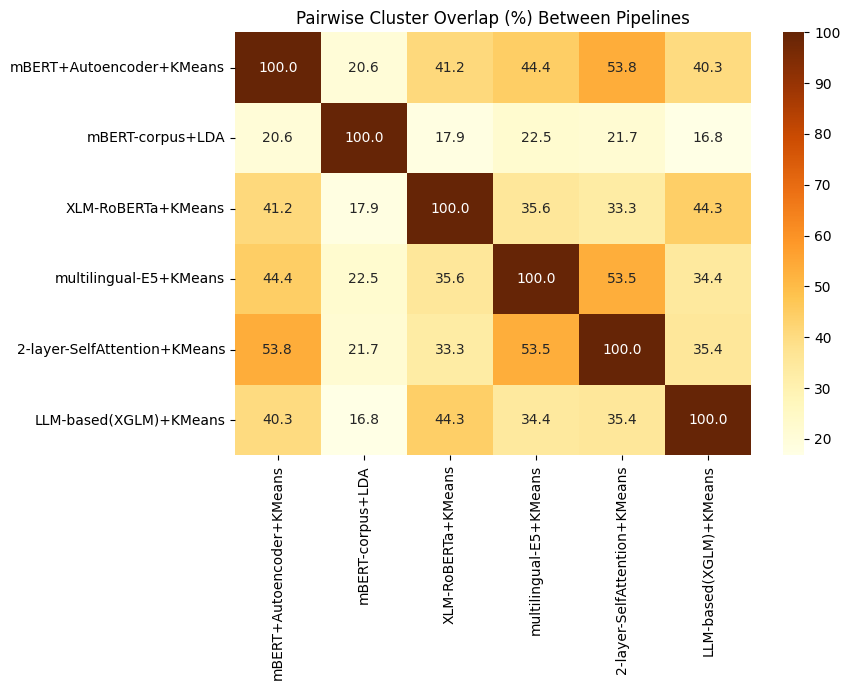


=== MASTER COMPARISON TABLE ===
                    Pipeline  Topics/K alpha beta  Epochs  Learning Rate    MSE  Coherence (c_v)  Avg Overlap w/ Others (%)
    mBERT+Autoencoder+KMeans        10  None None     5.0          0.001 0.2789           0.4382                       40.1
            mBERT-corpus+LDA        10  None None     NaN            NaN    NaN           0.3857                       19.9
          XLM-RoBERTa+KMeans        10  None None     NaN            NaN    NaN           0.3919                       34.4
      multilingual-E5+KMeans        10  None None     NaN            NaN    NaN           0.4304                       38.1
2-layer-SelfAttention+KMeans        10  None None     NaN            NaN    NaN           0.4350                       39.5
      LLM-based(XGLM)+KMeans        10  None None     NaN            NaN    NaN           0.4080                       34.2

=== RANKED PIPELINES (composite score) ===
                    Pipeline  Coherence (c_v)  Avg Over

In [1]:
# %% [markdown]
# # Full Pipeline — Single-Run Script
#
# End-to-end, single-file version of the whole workflow:
#
# 0. Translate Italian tweets to English, keeping a few Italian words
#    per tweet (code-mixed), producing the canonical dataset used below.
# 1. mBERT embeddings (shared by several pipelines).
# 2. mBERT + Autoencoder (768->64) + K-Means.
# 3. mBERT-corpus LDA (fine-tuned alpha/beta, K=10).
# 4. XLM-RoBERTa + K-Means.
# 5. multilingual-E5 + K-Means.
# 6. 2-layer Self-Attention (self-supervised, trained from scratch) + K-Means.
# 7. LLM-based embeddings (XGLM-564M, unsupervised feature extraction) + K-Means.
# 8. Comparison table: Topics/K, alpha/beta, Epochs/LR/MSE, Coherence Score,
#    pairwise Overlap (%) between pipelines.
#
# Every expensive step caches its output to disk first and reloads it on
# re-run instead of recomputing, so this script is safe to re-run after a
# Colab/Kaggle session interruption. Toggle the RUN_* flags below to skip
# stages you don't need this session.
#
# Works in Google Colab and Kaggle Notebooks. GPU strongly recommended.

# %%
# ============================================================
# 0. SETUP — install & import everything once
# ============================================================
!pip install -q transformers torch scikit-learn pandas numpy matplotlib seaborn \
    scipy gensim nltk openpyxl ftfy langdetect sentencepiece sacremoses

import os
import re
import time
import random
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from transformers import AutoTokenizer, AutoModel, MarianMTModel, MarianTokenizer
from langdetect import detect, DetectorFactory

from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.model_selection import train_test_split
from scipy.optimize import linear_sum_assignment
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

import matplotlib.pyplot as plt
import seaborn as sns

try:
    import ftfy
    HAS_FTFY = True
except ImportError:
    HAS_FTFY = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DetectorFactory.seed = SEED

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# %%
# ============================================================
# 1. CONFIG — everything in one place
# ============================================================
RAW_DATA_PATH = "/kaggle/input/datasets/szishanali/tweetsdataset1/TweetsDataset.xlsx"   # <-- EDIT if path differs
RAW_TEXT_COL = "Content"
LABEL_COL = "Classification"
ID_COL = "TwitterId"

DEDUPLICATE = True
SAMPLE_SIZE = None    # set an int (e.g. 5000) for a quick end-to-end test run

# Stage toggles — set False to skip a stage this session (its cached output
# will be reused by later stages if present).
RUN_TRANSLATION = True
RUN_AUTOENCODER = True
RUN_LDA = True
RUN_XLMR = True
RUN_E5 = True
RUN_SELF_ATTN = True
RUN_LLM = True
RUN_COMPARISON = True

N_CLUSTERS = 10
MAX_LEN = 64   # tweets are short; 128 was mostly padding waste

# Speed settings — fp16 roughly halves memory & lets batch size go up on a
# free-tier T4/P100. Only affects inference (embedding extraction) directly;
# training loops (Autoencoder, Self-Attention) use torch.autocast AMP instead.
USE_FP16 = True
COHERENCE_SAMPLE_SIZE = 100000   # cap docs fed to gensim CoherenceModel (c_v is O(n) sliding-window and dominates runtime on the full 130K corpus)

# -- Translation / code-mixing --
TRANSLATION_MODEL = "Helsinki-NLP/opus-mt-it-en"
TRANSLATE_BATCH_SIZE = 128
MIN_ITALIAN_WORDS_KEPT, MAX_ITALIAN_WORDS_KEPT = 1, 3
MIN_WORD_LEN = 4
TRANSLATED_XLSX = "TweetsDataset_translated_mixed.xlsx"
TEXT_COL = "Content_EN_mix"   # column used by every pipeline from here on

# -- mBERT embeddings (shared) --
MBERT_MODEL_NAME = "bert-base-multilingual-cased"
MBERT_EMB_PATH = "mbert_embeddings.npy"

# -- Autoencoder --
LATENT_DIM = 64
AE_EPOCHS = 5
AE_LR = 1e-3
AE_BATCH_SIZE = 64
AE_LATENT_PATH = "autoencoder_latent_features.npy"

# -- LDA --
LDA_TOPICS = N_CLUSTERS
LDA_TUNING_CSV = "lda_tuning_results.csv"

# -- XLM-R / E5 / LLM --
XLMR_MODEL_NAME = "xlm-roberta-base"
E5_MODEL_NAME = "intfloat/multilingual-e5-base"
LLM_MODEL_NAME = "facebook/xglm-564M"
EMB_BATCH_SIZE = 64   # doubled vs. before; fp16 makes this safe on a T4

# -- Self-Attention (self-supervised) --
SA_D_MODEL, SA_N_HEADS, SA_FFN_DIM, SA_N_LAYERS = 128, 4, 256, 2
SA_EPOCHS, SA_LR, SA_BATCH_SIZE, SA_MASK_PROB = 5, 1e-3, 64, 0.15

RESULTS_CSV = "clustering_results.csv"
FINAL_DATASET_XLSX = "final_all_pipelines_comparison.xlsx"
FINAL_DATASET_CSV = "final_all_pipelines_comparison.csv"

# %%
# ============================================================
# 2. SHARED HELPER FUNCTIONS
# ============================================================
def fix_mojibake(text):
    if HAS_FTFY:
        return ftfy.fix_text(text)
    try:
        return text.encode("cp1252", errors="ignore").decode("utf-8", errors="ignore")
    except Exception:
        return text

def clean_tweet(text):
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"RT\s+@\w+:?", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

def load_model_for_inference(model_cls, model_name, **kwargs):
    """Load a HF model for inference-only embedding extraction, in fp16 on
    GPU when enabled (roughly halves memory, frees up room for bigger
    batches — the single biggest speedup available on a free T4/P100)."""
    model = model_cls.from_pretrained(model_name, **kwargs).to(device)
    if USE_FP16 and device.type == "cuda":
        model = model.half()
    model.eval()
    return model

@torch.inference_mode()
def encode_with_hf_model(text_list, tokenizer, model, prefix="", batch_size=EMB_BATCH_SIZE,
                          normalize=False, max_len=MAX_LEN):
    all_embs = []
    for i in range(0, len(text_list), batch_size):
        batch = [prefix + t for t in text_list[i:i + batch_size]]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=max_len,
                         return_tensors="pt").to(device)
        out = model(**enc)
        pooled = mean_pool(out.last_hidden_state.float(), enc["attention_mask"])
        if normalize:
            pooled = F.normalize(pooled, p=2, dim=1)
        all_embs.append(pooled.cpu().numpy())
        if (i // batch_size) % 30 == 0:
            print(f"    embedded {i + len(batch)}/{len(text_list)}")
    return np.vstack(all_embs)

all_results = {}   # model_tag -> results dict, built up as each pipeline runs

def run_kmeans_and_evaluate(embeddings, model_tag, true_labels, extra_info=None, k=N_CLUSTERS):
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    cluster_assignments = kmeans.fit_predict(embeddings)
    print(f"  [{model_tag}] K-Means done (K={k}). Coherence Score computed later "
          f"in the comparison stage for all pipelines at once.")

    results = {"model": model_tag, "embedding_dim": embeddings.shape[1], "k_clusters": k}
    if extra_info:
        results.update(extra_info)

    all_results[model_tag] = results
    return cluster_assignments, results

def cluster_overlap_pct(labels_a, labels_b):
    contingency = pd.crosstab(pd.Series(labels_a), pd.Series(labels_b))
    cost = -contingency.values
    row_ind, col_ind = linear_sum_assignment(cost)
    matched = contingency.values[row_ind, col_ind].sum()
    return 100 * matched / len(labels_a)

def top_words_per_cluster_ctfidf(cluster_labels, tokenized_docs, top_n=10):
    cluster_ids = sorted(set(cluster_labels))
    cluster_word_counts = {c: {} for c in cluster_ids}
    for c, tokens in zip(cluster_labels, tokenized_docs):
        for tok in tokens:
            cluster_word_counts[c][tok] = cluster_word_counts[c].get(tok, 0) + 1
    vocab = set()
    for c in cluster_ids:
        vocab.update(cluster_word_counts[c].keys())
    doc_freq_global = {tok: sum(1 for c in cluster_ids if cluster_word_counts[c].get(tok, 0) > 0)
                        for tok in vocab}
    n_clusters_total = len(cluster_ids)
    topics = []
    for c in cluster_ids:
        total_in_cluster = sum(cluster_word_counts[c].values()) or 1
        scores = {}
        for tok, count in cluster_word_counts[c].items():
            tf = count / total_in_cluster
            idf = np.log(1 + n_clusters_total / (1 + doc_freq_global[tok]))
            scores[tok] = tf * idf
        topics.append(sorted(scores, key=scores.get, reverse=True)[:top_n])
    return topics

def compute_coherence(cluster_labels, tokenized_docs, dictionary, top_n=10):
    topics = top_words_per_cluster_ctfidf(cluster_labels, tokenized_docs, top_n=top_n)
    topics = [t for t in topics if len(t) >= 2]
    if len(topics) == 0:
        return np.nan
    cm = CoherenceModel(topics=topics, texts=tokenized_docs, dictionary=dictionary, coherence="c_v")
    return cm.get_coherence()

def tokenize_simple(text):
    return re.findall(r"[A-Za-zÀ-ÿ]{3,}", str(text).lower())

# %%
# ============================================================
# 3. LOAD, TRANSLATE & CODE-MIX (cached — skips if output already exists)
# ============================================================
if os.path.exists(TRANSLATED_XLSX):
    print(f"Found cached {TRANSLATED_XLSX} — loading it instead of re-translating.")
    df = pd.read_excel(TRANSLATED_XLSX)
elif RUN_TRANSLATION:
    df = pd.read_excel(RAW_DATA_PATH)
    df = df.dropna(subset=[RAW_TEXT_COL]).reset_index(drop=True)

    if DEDUPLICATE:
        before = len(df)
        df = df.drop_duplicates(subset=[RAW_TEXT_COL]).reset_index(drop=True)
        print(f"Removed {before - len(df)} duplicate tweets ({before} -> {len(df)})")

    df[RAW_TEXT_COL] = df[RAW_TEXT_COL].astype(str).apply(fix_mojibake)

    if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
        df = df.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
        print(f"Subsampled to {len(df)} rows")

    print("Detecting language per tweet...")
    def safe_detect(text):
        try:
            stripped = re.sub(r"http\S+|www\.\S+|@\w+|#\w+", "", text).strip()
            if len(stripped) < 8:
                return "unknown"
            return detect(stripped)
        except Exception:
            return "unknown"
    df["detected_lang"] = df[RAW_TEXT_COL].apply(safe_detect)
    is_italian = df["detected_lang"] == "it"
    print(f"{is_italian.sum()} Italian tweets to translate; {(~is_italian).sum()} left unchanged")

    ITALIAN_STOPWORDS = set("""
    a ad al alla allo ai agli agl' all' alle con col coi da dal dallo dall'
    dagli dai dagl' dalle di del dello dell' degli delle in nel nello nell'
    negli nella nelle su sul sullo sull' sugli sulla sulle per tra fra
    un uno una un' e ed o od che chi cui non come dove quando gia anche
    piu meno molto poco tanto tutto tutti tutta tutte questo questi
    questa queste quello quelli quella quelle io tu lui lei noi voi loro
    mi ti si ci vi lo la le li gli ne del della dei delle sono sei siamo
    siete essere stato stata stati state ho hai ha abbiamo avete hanno
    essendo avendo era erano ero eri eravamo eravate perche quindi
    mentre dopo prima ancora sempre mai qui qua li la ma pero se rt via
    """.split())
    WORD_RE = re.compile(r"[A-Za-zÀ-ÿ]+")

    def pick_keep_words(original_text):
        cleaned = re.sub(r"http\S+|www\.\S+|@\w+|#\w+|\bRT\b", " ", original_text)
        candidates = [w for w in WORD_RE.findall(cleaned)
                      if len(w) >= MIN_WORD_LEN and w.lower() not in ITALIAN_STOPWORDS]
        if not candidates:
            return []
        k = min(len(candidates), random.randint(MIN_ITALIAN_WORDS_KEPT, MAX_ITALIAN_WORDS_KEPT))
        return random.sample(candidates, k)

    tokenizer_mt = MarianTokenizer.from_pretrained(TRANSLATION_MODEL)
    translator = load_model_for_inference(MarianMTModel, TRANSLATION_MODEL)

    @torch.no_grad()
    def translate_batch(text_list, batch_size=TRANSLATE_BATCH_SIZE):
        outputs = []
        for i in range(0, len(text_list), batch_size):
            batch = text_list[i:i + batch_size]
            enc = tokenizer_mt(batch, return_tensors="pt", padding=True,
                                truncation=True, max_length=MAX_LEN).to(device)
            gen = translator.generate(**enc, max_length=MAX_LEN, num_beams=1)
            outputs.extend(tokenizer_mt.batch_decode(gen, skip_special_tokens=True))
            if (i // batch_size) % 30 == 0:
                print(f"    translated {i + len(batch)}/{len(text_list)}")
        return outputs

    italian_idx = df.index[is_italian].tolist()
    italian_texts = df.loc[italian_idx, RAW_TEXT_COL].tolist()
    print(f"Translating {len(italian_texts)} Italian tweets...")
    translated_full = translate_batch(italian_texts)

    keep_words_per_tweet = [pick_keep_words(t) for t in italian_texts]
    flat_words, word_owner = [], []
    for local_i, words in enumerate(keep_words_per_tweet):
        for w in words:
            flat_words.append(w)
            word_owner.append(local_i)
    print(f"Translating {len(flat_words)} individual keep-words for code-mixing...")
    translated_words = translate_batch(flat_words) if flat_words else []

    word_translation_map = {}
    for owner, it_word, en_word in zip(word_owner, flat_words, translated_words):
        word_translation_map.setdefault(owner, []).append((it_word, en_word.strip()))

    def insert_italian_words(english_sentence, word_pairs):
        result = english_sentence
        for it_word, en_word in word_pairs:
            en_word_clean = re.sub(r"[^\w]", "", en_word)
            if not en_word_clean:
                continue
            pattern = re.compile(rf"\b{re.escape(en_word_clean)}\b", flags=re.IGNORECASE)
            if pattern.search(result):
                result = pattern.sub(it_word, result, count=1)
        return result

    mixed_texts = [insert_italian_words(base, word_translation_map.get(i, []))
                   for i, base in enumerate(translated_full)]

    df[TEXT_COL] = df[RAW_TEXT_COL]
    for idx, mixed in zip(italian_idx, mixed_texts):
        df.at[idx, TEXT_COL] = mixed
    df["was_translated"] = False
    df.loc[italian_idx, "was_translated"] = True

    df.to_excel(TRANSLATED_XLSX, index=False)
    df.to_csv(TRANSLATED_XLSX.replace(".xlsx", ".csv"), index=False)
    print(f"Saved {TRANSLATED_XLSX}")

    del translator
    if device.type == "cuda":
        torch.cuda.empty_cache()
else:
    raise FileNotFoundError(
        f"{TRANSLATED_XLSX} not found and RUN_TRANSLATION=False — "
        "either enable RUN_TRANSLATION or provide the file."
    )

if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
    df = df.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)

texts_clean = [clean_tweet(str(t)) for t in df[TEXT_COL].astype(str).tolist()]
df["text_clean"] = texts_clean

has_labels = LABEL_COL in df.columns
if has_labels:
    unique_labels = sorted(df[LABEL_COL].astype(str).unique())
    label_to_id = {lab: i for i, lab in enumerate(unique_labels)}
    true_labels = df[LABEL_COL].astype(str).map(label_to_id).values
    print(f"\n{len(unique_labels)} ground-truth classes found (used only for post-hoc evaluation).")
else:
    true_labels = None
    print("\nNo label column found — running fully unsupervised.")

print(f"Total documents for all pipelines: {len(df)}")

# %%
# ============================================================
# 4. mBERT EMBEDDINGS (shared by Autoencoder pipeline + LDA vocabulary/topics)
# ============================================================
if os.path.exists(MBERT_EMB_PATH):
    mbert_embeddings = np.load(MBERT_EMB_PATH)
    if mbert_embeddings.shape[0] != len(df):
        print("Cached mBERT embeddings size mismatch — regenerating.")
        mbert_embeddings = None
else:
    mbert_embeddings = None

if mbert_embeddings is None:
    print("\nGenerating mBERT embeddings (768-dim)...")
    tok_mbert = AutoTokenizer.from_pretrained(MBERT_MODEL_NAME)
    model_mbert = load_model_for_inference(AutoModel, MBERT_MODEL_NAME)
    t0 = time.time()
    mbert_embeddings = encode_with_hf_model(texts_clean, tok_mbert, model_mbert, batch_size=EMB_BATCH_SIZE)
    print(f"Done in {time.time()-t0:.1f}s. Shape: {mbert_embeddings.shape}")
    np.save(MBERT_EMB_PATH, mbert_embeddings)
    del model_mbert
    if device.type == "cuda":
        torch.cuda.empty_cache()

# %%
# ============================================================
# 5. mBERT + AUTOENCODER (768 -> 64) + K-MEANS
# ============================================================
if RUN_AUTOENCODER:
    print("\n=== Pipeline: mBERT + Autoencoder + K-Means ===")

    class Autoencoder(nn.Module):
        def __init__(self, input_dim=768, latent_dim=64):
            super().__init__()
            self.encoder = nn.Sequential(nn.Linear(input_dim, 256), nn.ReLU(),
                                          nn.Linear(256, latent_dim))
            self.decoder = nn.Sequential(nn.Linear(latent_dim, 256), nn.ReLU(),
                                          nn.Linear(256, input_dim))
        def forward(self, x):
            z = self.encoder(x)
            return self.decoder(z), z

    if os.path.exists(AE_LATENT_PATH):
        latent = np.load(AE_LATENT_PATH)
        final_mse = None
        if latent.shape[0] != len(df):
            latent = None
    else:
        latent = None

    if latent is None:
        emb_mean = mbert_embeddings.mean(axis=0, keepdims=True)
        emb_std = mbert_embeddings.std(axis=0, keepdims=True) + 1e-8
        embeddings_norm = (mbert_embeddings - emb_mean) / emb_std

        X = torch.tensor(embeddings_norm, dtype=torch.float32)
        loader = DataLoader(TensorDataset(X), batch_size=AE_BATCH_SIZE, shuffle=True)

        ae = Autoencoder(input_dim=mbert_embeddings.shape[1], latent_dim=LATENT_DIM).to(device)
        optimizer = torch.optim.AdamW(ae.parameters(), lr=AE_LR)
        criterion = nn.MSELoss()

        print("Training Autoencoder...")
        ae.train()
        history = []
        for epoch in range(1, AE_EPOCHS + 1):
            epoch_loss = 0.0
            for (batch,) in loader:
                batch = batch.to(device)
                optimizer.zero_grad()
                recon, _ = ae(batch)
                loss = criterion(recon, batch)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * batch.size(0)
            epoch_loss /= len(X)
            history.append(epoch_loss)
            print(f"  Epoch {epoch}/{AE_EPOCHS} - MSE loss: {epoch_loss:.4f}")
        final_mse = history[-1]

        ae.eval()
        with torch.no_grad():
            _, latent = ae(X.to(device))
            latent = latent.cpu().numpy()
        np.save(AE_LATENT_PATH, latent)

        del ae
        if device.type == "cuda":
            torch.cuda.empty_cache()

    clusters_ae, results_ae = run_kmeans_and_evaluate(
        latent, "mBERT+Autoencoder+KMeans", true_labels,
        extra_info={"epochs": AE_EPOCHS, "learning_rate": AE_LR,
                    "mse": round(final_mse, 4) if final_mse is not None else None},
    )
    df["cluster_autoencoder"] = clusters_ae

# %%
# ============================================================
# 6. mBERT-CORPUS LDA (fine-tuned alpha/beta, K=10)
# ============================================================
if RUN_LDA:
    print("\n=== Pipeline: mBERT-corpus LDA ===")

    ITALIAN_STOPWORDS_LDA = set("""
    a ad al alla allo ai agli agl' all' alle con col coi da dal dallo dall'
    dagli dai dagl' dalle di del dello dell' degli delle in nel nello nell'
    negli nella nelle su sul sullo sull' sugli sulla sulle per tra fra
    un uno una un' e ed o od che chi cui non come dove quando gia anche
    piu meno molto poco tanto tutto tutti tutta tutte questo questi
    questa queste quello quelli quella quelle io tu lui lei noi voi loro
    mi ti si ci vi lo la le li gli ne del della dei delle sono sei siamo
    siete essere stato stata stati state ho hai ha abbiamo avete hanno
    essendo avendo era erano ero eri eravamo eravate perche quindi
    mentre dopo prima ancora sempre mai qui qua li la ma pero se rt via
    """.split())
    STOPWORDS = list(ITALIAN_STOPWORDS_LDA) + list(
        CountVectorizer(stop_words="english").get_stop_words() or []
    )
    vectorizer = CountVectorizer(max_df=0.90, min_df=5, stop_words=STOPWORDS,
                                  token_pattern=r"(?u)\b[^\W\d_][^\W\d_]+\b")
    dtm = vectorizer.fit_transform(df["text_clean"])
    vocab = vectorizer.get_feature_names_out()
    print(f"Document-term matrix shape: {dtm.shape}")

    dtm_train, dtm_val = train_test_split(dtm, test_size=0.2, random_state=SEED)
    param_grid = [
        {"doc_topic_prior": None, "topic_word_prior": None, "learning_decay": 0.7},
        {"doc_topic_prior": 0.1, "topic_word_prior": 0.01, "learning_decay": 0.7},
        {"doc_topic_prior": 0.1, "topic_word_prior": 0.1, "learning_decay": 0.5},
        {"doc_topic_prior": 0.5, "topic_word_prior": 0.01, "learning_decay": 0.7},
        {"doc_topic_prior": 0.05, "topic_word_prior": 0.05, "learning_decay": 0.9},
    ]
    print("Tuning LDA hyperparameters...")
    tuning_rows, best_score, best_params = [], -np.inf, None
    for params in param_grid:
        lda = LatentDirichletAllocation(
            n_components=LDA_TOPICS, doc_topic_prior=params["doc_topic_prior"],
            topic_word_prior=params["topic_word_prior"], learning_decay=params["learning_decay"],
            learning_method="online", max_iter=25, random_state=SEED, n_jobs=1,   # <-- FIX: n_jobs=-1
            # spawns worker processes for LDA's E-step; in Colab/Kaggle notebooks these
            # workers frequently fail to pickle the sparse dtm/random_state cleanly, which
            # surfaces as a BrokenProcessPool / TerminatedWorkerError (or a silent hang)
            # partway through the hyperparameter grid. n_jobs=1 runs single-process and is
            # reliable; it's a bit slower but the grid here is only 5 combinations.
        )
        lda.fit(dtm_train)
        ll = lda.score(dtm_val)
        perplexity = lda.perplexity(dtm_val)
        row = {"doc_topic_prior (alpha)": params["doc_topic_prior"] or f"1/{LDA_TOPICS} (default)",
               "topic_word_prior (beta)": params["topic_word_prior"] or f"1/{LDA_TOPICS} (default)",
               "learning_decay": params["learning_decay"],
               "held_out_log_likelihood": round(ll, 1), "perplexity": round(perplexity, 1)}
        tuning_rows.append(row)
        print(" ", row)
        if ll > best_score:
            best_score, best_params = ll, params

    tuning_df = pd.DataFrame(tuning_rows)
    tuning_df.to_csv(LDA_TUNING_CSV, index=False)
    print("Best LDA hyperparameters:", best_params)

    final_lda = LatentDirichletAllocation(
        n_components=LDA_TOPICS, doc_topic_prior=best_params["doc_topic_prior"],
        topic_word_prior=best_params["topic_word_prior"], learning_decay=best_params["learning_decay"],
        learning_method="online", max_iter=50, random_state=SEED, n_jobs=1,   # <-- was -1
    )
    doc_topic_dist = final_lda.fit_transform(dtm)
    lda_clusters = doc_topic_dist.argmax(axis=1)
    df["cluster_lda"] = lda_clusters

    def top_words_per_topic(model, vocab, n_words=12):
        return {idx: [vocab[i] for i in topic.argsort()[::-1][:n_words]]
                for idx, topic in enumerate(model.components_)}
    topic_words = top_words_per_topic(final_lda, vocab)
    pd.DataFrame({f"topic_{t}": w for t, w in topic_words.items()}).to_csv(
        "lda_topic_top_words.csv", index=False)

    results_lda = {
        "model": "mBERT-corpus+LDA", "k_clusters": LDA_TOPICS,
        "doc_topic_prior": best_params["doc_topic_prior"], "topic_word_prior": best_params["topic_word_prior"],
        "held_out_log_likelihood": round(best_score, 1),
    }
    all_results["mBERT-corpus+LDA"] = results_lda

# %%
# ============================================================
# 7. XLM-ROBERTA + K-MEANS
# ============================================================
if RUN_XLMR:
    print("\n=== Pipeline: XLM-RoBERTa + K-Means ===")
    if os.path.exists("xlmr_embeddings.npy"):
        emb_xlmr = np.load("xlmr_embeddings.npy")
    else:
        tok = AutoTokenizer.from_pretrained(XLMR_MODEL_NAME)
        model = load_model_for_inference(AutoModel, XLMR_MODEL_NAME)
        emb_xlmr = encode_with_hf_model(texts_clean, tok, model)
        np.save("xlmr_embeddings.npy", emb_xlmr)
        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()
    clusters_xlmr, _ = run_kmeans_and_evaluate(
        emb_xlmr, "XLM-RoBERTa+KMeans", true_labels, extra_info={"backbone": XLMR_MODEL_NAME})
    df["cluster_xlmr"] = clusters_xlmr

# %%
# ============================================================
# 8. MULTILINGUAL-E5 + K-MEANS
# ============================================================
if RUN_E5:
    print("\n=== Pipeline: multilingual-E5 + K-Means ===")
    if os.path.exists("e5_embeddings.npy"):
        emb_e5 = np.load("e5_embeddings.npy")
    else:
        tok = AutoTokenizer.from_pretrained(E5_MODEL_NAME)
        model = load_model_for_inference(AutoModel, E5_MODEL_NAME)
        emb_e5 = encode_with_hf_model(texts_clean, tok, model, prefix="query: ", normalize=True)
        np.save("e5_embeddings.npy", emb_e5)
        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()
    clusters_e5, _ = run_kmeans_and_evaluate(
        emb_e5, "multilingual-E5+KMeans", true_labels, extra_info={"backbone": E5_MODEL_NAME})
    df["cluster_e5"] = clusters_e5

# %%
# ============================================================
# 9. 2-LAYER SELF-ATTENTION (SELF-SUPERVISED, TRAINED FROM SCRATCH) + K-MEANS
# ============================================================
if RUN_SELF_ATTN:
    print("\n=== Pipeline: 2-layer Self-Attention (self-supervised) + K-Means ===")
    if os.path.exists("self_attention_embeddings.npy"):
        emb_self_attn = np.load("self_attention_embeddings.npy")
        sa_final_loss = None
    else:
        sa_tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
        VOCAB_SIZE = sa_tokenizer.vocab_size
        PAD_ID, MASK_ID = sa_tokenizer.pad_token_id, sa_tokenizer.mask_token_id
        CLS_ID, SEP_ID = sa_tokenizer.cls_token_id, sa_tokenizer.sep_token_id

        enc = sa_tokenizer(texts_clean, padding="max_length", truncation=True,
                            max_length=MAX_LEN, return_tensors="pt")
        input_ids_all, attn_mask_all = enc["input_ids"], enc["attention_mask"]

        class SelfAttentionEncoder(nn.Module):
            def __init__(self, vocab_size, d_model, n_heads, ffn_dim, n_layers, max_len):
                super().__init__()
                self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
                self.pos_emb = nn.Embedding(max_len, d_model)
                layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
                                                    dim_feedforward=ffn_dim, batch_first=True,
                                                    activation="gelu")
                self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers,
                                                      enable_nested_tensor=False)   # <-- FIX 1
                self.mlm_head = nn.Linear(d_model, vocab_size)
            def forward(self, input_ids, attention_mask):
                positions = torch.arange(input_ids.size(1), device=input_ids.device).unsqueeze(0)
                x = self.token_emb(input_ids) + self.pos_emb(positions)
                pad_mask = (attention_mask == 0).to(x.device)                     # <-- FIX 2
                hidden = self.encoder(x, src_key_padding_mask=pad_mask)
                return hidden, self.mlm_head(hidden)

        def mask_tokens(input_ids, mask_prob=SA_MASK_PROB):
            labels = input_ids.clone()
            special = (input_ids == PAD_ID) | (input_ids == CLS_ID) | (input_ids == SEP_ID)
            prob_matrix = torch.full(input_ids.shape, mask_prob, device=input_ids.device)   # <-- FIX
            prob_matrix.masked_fill_(special, 0.0)
            masked_positions = torch.bernoulli(prob_matrix).bool()
            labels[~masked_positions] = -100
            masked_input = input_ids.clone()
            masked_input[masked_positions] = MASK_ID
            return masked_input, labels

        sa_model = SelfAttentionEncoder(VOCAB_SIZE, SA_D_MODEL, SA_N_HEADS, SA_FFN_DIM,
                                         SA_N_LAYERS, MAX_LEN).to(device)
        sa_optimizer = torch.optim.AdamW(sa_model.parameters(), lr=SA_LR)
        sa_loader = DataLoader(TensorDataset(input_ids_all, attn_mask_all),
                                batch_size=SA_BATCH_SIZE, shuffle=True)

        # Mixed-precision (AMP) training: this model's output layer is
        # vocab_size-wide (~120K), so the loss computation is the real cost
        # here — autocast + GradScaler noticeably speeds this up on a T4.
        use_amp = USE_FP16 and device.type == "cuda"
        scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

        print("Training self-supervised self-attention encoder...")
        sa_model.train()
        sa_history = []
        for epoch in range(1, SA_EPOCHS + 1):
            epoch_loss, n_batches = 0.0, 0
            for batch_ids, batch_mask in sa_loader:
                batch_ids, batch_mask = batch_ids.to(device), batch_mask.to(device)
                masked_input, labels = mask_tokens(batch_ids)
                sa_optimizer.zero_grad()
                with torch.autocast(device_type=device.type, enabled=use_amp):
                    _, logits = sa_model(masked_input, batch_mask)
                    loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE), labels.view(-1), ignore_index=-100)
                scaler.scale(loss).backward()
                scaler.step(sa_optimizer)
                scaler.update()
                epoch_loss += loss.item()
                n_batches += 1
            epoch_loss /= max(n_batches, 1)
            sa_history.append(epoch_loss)
            print(f"  Epoch {epoch}/{SA_EPOCHS} - masked-token CE loss: {epoch_loss:.4f}")
        sa_final_loss = sa_history[-1]

        sa_model.eval()
        all_sa_embs = []
        with torch.no_grad():
            for i in range(0, len(df), EMB_BATCH_SIZE):
                batch_ids = input_ids_all[i:i + EMB_BATCH_SIZE].to(device)
                batch_mask = attn_mask_all[i:i + EMB_BATCH_SIZE].to(device)
                hidden, _ = sa_model(batch_ids, batch_mask)
                all_sa_embs.append(mean_pool(hidden, batch_mask).cpu().numpy())
        emb_self_attn = np.vstack(all_sa_embs)
        np.save("self_attention_embeddings.npy", emb_self_attn)
        del sa_model
        if device.type == "cuda":
            torch.cuda.empty_cache()

    clusters_sa, _ = run_kmeans_and_evaluate(
        emb_self_attn, "2-layer-SelfAttention(self-supervised)+KMeans", true_labels,
        extra_info={"epochs": SA_EPOCHS, "learning_rate": SA_LR,
                    "final_mlm_loss": round(sa_final_loss, 4) if sa_final_loss is not None else None},
    )
    df["cluster_self_attn"] = clusters_sa

# %%
# ============================================================
# 10. LLM-BASED EMBEDDINGS (XGLM-564M, unsupervised) + K-MEANS
# ============================================================
if RUN_LLM:
    print("\n=== Pipeline: LLM-based embeddings (XGLM-564M) + K-Means ===")
    if os.path.exists("llm_embeddings.npy"):
        emb_llm = np.load("llm_embeddings.npy")
    else:
        tok = AutoTokenizer.from_pretrained(LLM_MODEL_NAME)
        if tok.pad_token is None:
            tok.pad_token = tok.eos_token
        model = load_model_for_inference(AutoModel, LLM_MODEL_NAME)
        emb_llm = encode_with_hf_model(texts_clean, tok, model, batch_size=16)
        np.save("llm_embeddings.npy", emb_llm)
        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()
    clusters_llm, _ = run_kmeans_and_evaluate(
        emb_llm, "LLM-based(XGLM-564M)+KMeans", true_labels, extra_info={"backbone": LLM_MODEL_NAME})
    df["cluster_llm"] = clusters_llm

# %%
# ============================================================
# 11. COMPARISON: COHERENCE, OVERLAP, MASTER TABLE
# ============================================================
if RUN_COMPARISON:
    print("\n=== Building comparison table across all pipelines ===")
    CLUSTER_COLS = [c for c in ["cluster_autoencoder", "cluster_lda", "cluster_xlmr",
                                 "cluster_e5", "cluster_self_attn", "cluster_llm"]
                    if c in df.columns]
    PIPELINE_DISPLAY_NAMES = {
        "cluster_autoencoder": "mBERT+Autoencoder+KMeans",
        "cluster_lda": "mBERT-corpus+LDA",
        "cluster_xlmr": "XLM-RoBERTa+KMeans",
        "cluster_e5": "multilingual-E5+KMeans",
        "cluster_self_attn": "2-layer-SelfAttention+KMeans",
        "cluster_llm": "LLM-based(XGLM)+KMeans",
    }

    # Coherence (c_v) does sliding-window co-occurrence counting over the
    # WHOLE corpus passed to it — that cost dominates runtime on ~130K docs
    # and adds little accuracy past a representative sample, so cap it here.
    if len(df) > COHERENCE_SAMPLE_SIZE:
        coherence_sample_idx = df.sample(n=COHERENCE_SAMPLE_SIZE, random_state=SEED).index
        print(f"Coherence will be scored on a {COHERENCE_SAMPLE_SIZE}-doc sample "
              f"(of {len(df)}) to keep runtime bounded.")
    else:
        coherence_sample_idx = df.index

    tokenized_corpus = df.loc[coherence_sample_idx, "text_clean"].apply(tokenize_simple).tolist()
    gensim_dict = Dictionary(tokenized_corpus)
    gensim_dict.filter_extremes(no_below=5, no_above=0.9)

    print("Computing Coherence Score for every pipeline...")
    coherence_scores = {}
    for col in CLUSTER_COLS:
        cluster_labels_sample = df.loc[coherence_sample_idx, col].values
        coherence_scores[col] = compute_coherence(cluster_labels_sample, tokenized_corpus, gensim_dict)
        print(f"  {PIPELINE_DISPLAY_NAMES[col]}: coherence (c_v) = {coherence_scores[col]:.4f}")

    print("Computing pairwise overlap matrix...")
    overlap_matrix = pd.DataFrame(index=CLUSTER_COLS, columns=CLUSTER_COLS, dtype=float)
    for a, b in itertools.product(CLUSTER_COLS, CLUSTER_COLS):
        overlap_matrix.loc[a, b] = 100.0 if a == b else cluster_overlap_pct(df[a].values, df[b].values)
    overlap_matrix.index = [PIPELINE_DISPLAY_NAMES[c] for c in overlap_matrix.index]
    overlap_matrix.columns = [PIPELINE_DISPLAY_NAMES[c] for c in overlap_matrix.columns]
    overlap_matrix.to_csv("pairwise_overlap_matrix.csv")

    plt.figure(figsize=(9, 7))
    sns.heatmap(overlap_matrix, annot=True, fmt=".1f", cmap="YlOrBr")
    plt.title("Pairwise Cluster Overlap (%) Between Pipelines")
    plt.tight_layout()
    plt.savefig("pairwise_overlap_matrix.png", dpi=150)
    plt.show()

    avg_overlap = {col: overlap_matrix.loc[PIPELINE_DISPLAY_NAMES[col]].drop(PIPELINE_DISPLAY_NAMES[col]).mean()
                   for col in CLUSTER_COLS}

    rows = []
    for col in CLUSTER_COLS:
        name = PIPELINE_DISPLAY_NAMES[col]
        r = all_results.get(name, {})
        row = {
            "Pipeline": name,
            "Topics/K": N_CLUSTERS,
            "alpha": r.get("doc_topic_prior"),
            "beta": r.get("topic_word_prior"),
            "Epochs": r.get("epochs"),
            "Learning Rate": r.get("learning_rate"),
            "MSE": r.get("mse"),
            "Coherence (c_v)": round(coherence_scores[col], 4),
            "Avg Overlap w/ Others (%)": round(avg_overlap[col], 1),
        }
        rows.append(row)

    comparison_table = pd.DataFrame(rows)
    comparison_table.to_csv("master_comparison_table.csv", index=False)
    print("\n=== MASTER COMPARISON TABLE ===")
    print(comparison_table.to_string(index=False))

    # ranking / recommendation
    def minmax_norm(s):
        s = s.astype(float)
        rng = s.max() - s.min()
        return (s - s.min()) / rng if rng > 0 else s * 0

    rank_df = comparison_table.copy()
    rank_df["coh_norm"] = minmax_norm(rank_df["Coherence (c_v)"])
    rank_df["overlap_norm"] = minmax_norm(rank_df["Avg Overlap w/ Others (%)"])
    # Coherence is the primary quality signal now; overlap is a secondary
    # tie-breaker (low agreement with other pipelines can indicate an outlier
    # rather than a strictly worse model, hence the smaller weight).
    rank_df["composite_score"] = 0.85 * rank_df["coh_norm"] + 0.15 * rank_df["overlap_norm"]
    rank_df = rank_df.sort_values("composite_score", ascending=False).reset_index(drop=True)

    print("\n=== RANKED PIPELINES (composite score) ===")
    print(rank_df[["Pipeline", "Coherence (c_v)",
                    "Avg Overlap w/ Others (%)", "composite_score"]].to_string(index=False))
    print(f"\n>>> Highest-ranked pipeline this run: {rank_df.iloc[0]['Pipeline']}")

# %%
# ============================================================
# 12. SAVE FINAL DATASET FOR REPRODUCIBILITY
# ============================================================
save_cols = [ID_COL, TEXT_COL, "text_clean"] + ([LABEL_COL] if has_labels else []) + \
            [c for c in ["cluster_autoencoder", "cluster_lda", "cluster_xlmr",
                         "cluster_e5", "cluster_self_attn", "cluster_llm"] if c in df.columns]
final_df = df[save_cols]
final_df.to_excel(FINAL_DATASET_XLSX, index=False)
final_df.to_csv(FINAL_DATASET_CSV, index=False)

if all_results:
    pd.DataFrame(all_results.values()).to_csv(RESULTS_CSV, index=False)

print(f"\nSaved: {TRANSLATED_XLSX}, {FINAL_DATASET_XLSX}, {FINAL_DATASET_CSV}, "
      f"master_comparison_table.csv, pairwise_overlap_matrix.csv/.png, {RESULTS_CSV}")
